<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-297-Natural-Language-Processing/blob/main/FinSight_Agent_Prototype_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FinSight Agent — Prototype v3 (Hugging Face + free news APIs + dashboards + 4-language translation)

An autonomous research **agent**: it takes a goal, makes a plan, asks a human to approve it, collects real SEC data and news, runs NLP models, and writes a **cited** bull/bear brief (plus a Spanish version). Ideas borrowed from the paper *FinSight: Towards Real-World Financial Deep Research* (Jin et al.):

| Idea from the paper | Where it is here |
|---|---|
| **CAVM** — one shared memory for data, tools and agents | `SharedMemory` (Step 1) |
| Agents act by **writing code** that uses memory variables (`save_result`) | Analysis Agent (Step 6) |
| Multi-agent pipeline | Data → NLP → Analysis → Report agents (Steps 4–7) |
| **Two-stage writing** + citations locked to IDs + self-check | Report Agent (Step 7) |
| Professor: autonomous agent + **human in the loop** | Plan approval (Step 3), monitoring (Step 9), translation review flags (Step 10) |
| Multilingual output | Spanish, Chinese, Vietnamese, Hindi with quality checks (Step 10) |
| Visualizations | Financial, news, agent-memory and trust dashboards (Step 11) |

### Keys (all free) — store them in Colab **Secrets** (🔑 icon on the left), not in the code
| Secret name | What it unlocks | Where to get it |
|---|---|---|
| *(none)* | SEC EDGAR financial data — always on | no key needed |
| `HF_TOKEN` | LLM writes the report and answers questions (Hugging Face Inference Providers, small free monthly credits) | huggingface.co → Settings → Access Tokens → **fine-grained**, tick **"Make calls to Inference Providers"** |
| `FINNHUB_KEY` | Recent company news (main news source) | finnhub.io → sign up |
| `ALPHAVANTAGE_KEY` | Extra news with Alpha Vantage's own sentiment labels (small daily limit) | alphavantage.co → get free API key |

After adding a secret, switch on **Notebook access** for it. The NLP models (FinBERT, NER, topic classifier, English→Spanish translator) run **inside Colab for free** — no key or credits used. A GPU runtime (*Runtime → Change runtime type → T4 GPU*) makes them faster.

**Run:** put your name + email in `USER_AGENT`, then *Runtime → Run all*. Teaching prototype — not investment advice.

In [1]:
%pip install -q sentencepiece sacremoses sacrebleu   # translation models + translation quality metric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.8/867.8 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 4.9 MB/s eta 0:00:00


In [2]:
# ===================== CONFIG =====================
USER_AGENT   = "FinSight Team yourname@sjsu.edu"   # SEC requires a real name + email
TICKERS      = ["NVDA", "AMD"]
USER_GOAL    = "Compare NVIDIA and AMD's recent revenue growth, profitability and news"
AUTO_APPROVE = False   # True = skip the human-approval prompt
USE_LOCAL_NLP = True   # run FinBERT / NER / topic / translation models inside Colab (free)

# LLMs on Hugging Face Inference Providers, tried in order (change to any chat model in the HF Playground)
HF_CHAT_MODELS = ["openai/gpt-oss-20b", "Qwen/Qwen3-8B"]

# Keys: leave "" to read them from Colab Secrets (recommended when sharing the notebook)
HF_TOKEN = FINNHUB_KEY = ALPHAVANTAGE_KEY = ""

def secret(name, value=""):
    if value:
        return value
    try:
        from google.colab import userdata
        return userdata.get(name) or ""
    except Exception:          # not in Colab, secret missing, or notebook access not granted
        return ""

HF_TOKEN, FINNHUB_KEY, ALPHAVANTAGE_KEY = (secret("HF_TOKEN", HF_TOKEN), secret("FINNHUB_KEY", FINNHUB_KEY),
                                           secret("ALPHAVANTAGE_KEY", ALPHAVANTAGE_KEY))
for n, v in [("HF_TOKEN", HF_TOKEN), ("FINNHUB_KEY", FINNHUB_KEY), ("ALPHAVANTAGE_KEY", ALPHAVANTAGE_KEY)]:
    print(f"{n:17} {'✅ found' if v else '— not set (feature skipped)'}")
if "yourname" in USER_AGENT:
    print("⚠️  Put your real name + email in USER_AGENT, or SEC may block requests.")

HF_TOKEN          ✅ found
FINNHUB_KEY       ✅ found
ALPHAVANTAGE_KEY  ✅ found
⚠️  Put your real name + email in USER_AGENT, or SEC may block requests.


## Step 1 — Shared memory (the paper's CAVM idea)
One memory for every agent. Each item has a name, a description, the agent that made it, and a **source ID** (`S1`, `S2`, …) so every fact can be cited.

In [3]:
import re, time, datetime as dt
import requests
import pandas as pd
from IPython.display import Markdown, display

class SharedMemory:
    def __init__(self):
        self.vars, self.sources, self.log = {}, {}, []

    def add_source(self, citation, url):
        for sid, s in self.sources.items():          # same URL -> same ID
            if s["url"] == url:
                return sid
        sid = f"S{len(self.sources) + 1}"
        self.sources[sid] = {"citation": citation, "url": url}
        return sid

    def save(self, name, value, description, agent):
        self.vars[name] = {"value": value, "description": description, "agent": agent}
        self.log.append(f"[{agent}] saved '{name}'")

    def get(self, name, default=None):
        return self.vars[name]["value"] if name in self.vars else default

    def describe(self):
        return "\n".join(f"- {n}: {v['description']} (by {v['agent']})" for n, v in self.vars.items()) or "(empty)"

memory = SharedMemory()

def vname(ticker):  return re.sub(r"\W", "_", ticker.upper())              # BRK.B -> BRK_B
def cite(*ids):     return "".join(f"[{i}]" for i in dict.fromkeys(ids))   # "[S1][S2]", no duplicates
def fmt_usd(x):     return f"${x/1e9:,.2f}B" if abs(x) >= 1e9 else f"${x/1e6:,.1f}M"
print("Shared memory ready.")

Shared memory ready.


## Step 2 — Tools the agents can call
**Data:** SEC EDGAR (free) · Finnhub news · Alpha Vantage news.
**LLM:** Hugging Face Inference Providers (OpenAI-compatible endpoint).
**NLP models (run locally, free):** `ProsusAI/finbert` sentiment · `dslim/bert-base-NER` entities · `facebook/bart-large-mnli` zero-shot topic classification · `Helsinki-NLP/opus-mt-en-es` translation.

In [4]:
# ---------- SEC EDGAR ----------
HEADERS = {"User-Agent": USER_AGENT}

def sec_get(url):
    r = requests.get(url, headers=HEADERS, timeout=30)
    if r.status_code != 200:
        raise RuntimeError(f"SEC returned {r.status_code} for {url}. Check USER_AGENT (name + email).")
    time.sleep(0.2)                      # stay well under SEC's 10 requests/second limit
    return r.json()

_ticker_map = None
def get_cik(ticker):
    global _ticker_map
    if _ticker_map is None:
        data = sec_get("https://www.sec.gov/files/company_tickers.json")
        _ticker_map = {row["ticker"].upper(): (row["cik_str"], row["title"]) for row in data.values()}
    return _ticker_map[ticker.upper()]

def quarterly_series(facts, tags, unit="USD"):
    # 3-month values for whichever XBRL tag has the most recent data
    best = None
    for tag in tags:
        df = pd.DataFrame(facts["facts"].get("us-gaap", {}).get(tag, {}).get("units", {}).get(unit, []))
        if df.empty or "start" not in df:
            continue
        df = df.dropna(subset=["start"])
        df = df[(pd.to_datetime(df["end"]) - pd.to_datetime(df["start"])).dt.days.between(80, 100)]
        if df.empty:
            continue
        df = (df.sort_values("filed").drop_duplicates("end", keep="last").sort_values("end")
                .reset_index(drop=True).rename(columns={"val": "value"}))[["start", "end", "value", "form", "filed", "accn"]]
        df["tag"] = tag
        if best is None or df["end"].iloc[-1] > best["end"].iloc[-1]:
            best = df
    return best

def recent_filings(cik, forms=("10-K", "10-Q", "8-K"), since=None):
    rec = sec_get(f"https://data.sec.gov/submissions/CIK{cik:010d}.json")["filings"]["recent"]
    return [{"form": f, "date": d, "url": f"https://www.sec.gov/Archives/edgar/data/{cik}/{a.replace('-', '')}/{doc}"}
            for f, d, a, doc in zip(rec["form"], rec["filingDate"], rec["accessionNumber"], rec["primaryDocument"])
            if f in forms and (since is None or d > since)]

# ---------- News (free keys) ----------
def news_finnhub(ticker, days=14, n=6):
    if not FINNHUB_KEY:
        return []
    today = dt.date.today()
    r = requests.get("https://finnhub.io/api/v1/company-news", timeout=30,
                     params={"symbol": ticker, "from": str(today - dt.timedelta(days=days)), "to": str(today), "token": FINNHUB_KEY})
    if r.status_code != 200:
        print(f"  Finnhub HTTP {r.status_code}: {r.text[:120]}"); return []
    return [{"headline": a.get("headline", ""), "summary": a.get("summary", ""), "source": a.get("source", "Finnhub"),
             "url": a.get("url", ""), "av_label": None} for a in r.json()[:n] if a.get("headline")]

def news_alphavantage(ticker, n=4):
    if not ALPHAVANTAGE_KEY:
        return []
    r = requests.get("https://www.alphavantage.co/query", timeout=30,
                     params={"function": "NEWS_SENTIMENT", "tickers": ticker, "limit": 50, "apikey": ALPHAVANTAGE_KEY})
    data = r.json()
    if "feed" not in data:                       # rate limit or error message
        print("  Alpha Vantage:", data.get("Information") or data.get("Note") or data.get("Error Message") or data); return []
    return [{"headline": a.get("title", ""), "summary": a.get("summary", ""), "source": a.get("source", "Alpha Vantage"),
             "url": a.get("url", ""), "av_label": a.get("overall_sentiment_label")} for a in data["feed"][:n] if a.get("title")]

# ---------- LLM: Hugging Face Inference Providers ----------
def call_llm(prompt, max_tokens=1500):
    if not HF_TOKEN:
        return None
    for model in HF_CHAT_MODELS:
        try:
            r = requests.post("https://router.huggingface.co/v1/chat/completions", timeout=180,
                              headers={"Authorization": f"Bearer {HF_TOKEN}"},
                              json={"model": model, "max_tokens": max_tokens, "temperature": 0.2,
                                    "messages": [{"role": "user", "content": prompt}]})
            if r.status_code == 402:
                print("  HF: free monthly credits used up -> using the template instead."); return None
            if r.status_code != 200:
                print(f"  HF model {model}: HTTP {r.status_code} {r.text[:150]}"); continue
            text = r.json()["choices"][0]["message"].get("content") or ""
            text = re.sub(r"<think>.*?</think>", "", text, flags=re.S).strip()   # drop hidden reasoning if present
            if text:
                print(f"  (LLM used: {model})"); return text
        except Exception as e:
            print(f"  HF model {model} failed: {e}")
    return None

# ---------- Local NLP models (free, run in Colab) ----------
_models = {}
def _device():
    import torch
    return "cuda" if torch.cuda.is_available() else "cpu"

def _pipe(name, task, model_id):
    if name not in _models:
        from transformers import pipeline
        print(f"  loading {model_id} (first time only)...")
        _models[name] = pipeline(task, model=model_id, device=_device())
    return _models[name]

def finbert_sentiment(texts):                     # -> ["positive" | "negative" | "neutral", ...]
    out = _pipe("finbert", "text-classification", "ProsusAI/finbert")(texts)
    return [(o[0] if isinstance(o, list) else o)["label"].lower() for o in out]

def extract_entities(texts):                      # -> [[(entity, type), ...], ...]  types: ORG, PER, LOC, MISC
    out = _pipe("ner", "token-classification", "dslim/bert-base-NER")(texts, aggregation_strategy="simple")
    if out and isinstance(out[0], dict):
        out = [out]
    return [[(e["word"], e["entity_group"]) for e in ents if e["score"] > 0.8] for ents in out]

TOPICS = ["earnings results", "guidance or outlook", "new product or AI", "regulation or legal", "competition", "stock price move"]
def classify_topics(texts):                       # zero-shot text classification -> best topic per text
    out = _pipe("topic", "zero-shot-classification", "facebook/bart-large-mnli")(texts, candidate_labels=TOPICS)
    if isinstance(out, dict):
        out = [out]
    return [o["labels"][0] for o in out]

def translate_en_es(texts):                       # transformers v5 removed the translation pipeline -> use generate()
    if "mt" not in _models:
        from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
        print("  loading Helsinki-NLP/opus-mt-en-es (first time only)...")
        tok = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-es")
        _models["mt"] = (tok, AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-es").to(_device()))
    tok, model = _models["mt"]
    batch = tok(texts, return_tensors="pt", padding=True, truncation=True).to(model.device)
    return tok.batch_decode(model.generate(**batch, max_new_tokens=256), skip_special_tokens=True)

POS = {"beat", "beats", "record", "growth", "surge", "strong", "raises", "upgrade", "gain", "gains", "rally", "outperform"}
NEG = {"miss", "misses", "decline", "drop", "falls", "weak", "cut", "cuts", "downgrade", "loss", "lawsuit", "probe", "slump"}
def wordlist_sentiment(texts):                    # backup if the models can't load
    out = []
    for t in texts:
        w = re.findall(r"[a-z]+", t.lower()); s = sum(x in POS for x in w) - sum(x in NEG for x in w)
        out.append("positive" if s > 0 else "negative" if s < 0 else "neutral")
    return out

print("Tools ready.")

Tools ready.


## Step 3 — Planner + human in the loop
The agent proposes a plan and waits for approval before doing anything.

In [5]:
plan = [f"Collect quarterly revenue, net income and diluted EPS from SEC XBRL for {', '.join(TICKERS)}"]
if FINNHUB_KEY or ALPHAVANTAGE_KEY:
    plan.append(f"Collect recent news for {', '.join(TICKERS)} (" + " + ".join(
        s for s, k in [("Finnhub", FINNHUB_KEY), ("Alpha Vantage", ALPHAVANTAGE_KEY)] if k) + ")")
    plan.append("Run NLP on the news: FinBERT sentiment, named entities, topic classification")
plan += ["Analyze growth and margins (short notes with source IDs)",
         "Write a cited bull/bear brief" + (" with the LLM" if HF_TOKEN else " (template)") + ", check every citation",
         "Translate the key facts to Spanish"]

print(f"GOAL: {USER_GOAL}\n\nPROPOSED PLAN:")
for i, step in enumerate(plan, 1):
    print(f"  {i}. {step}")
APPROVED = AUTO_APPROVE or input("\nApprove this plan? (y/n): ").strip().lower().startswith("y")
print("✅ Approved — agents will run." if APPROVED else "❌ Not approved — change TICKERS/USER_GOAL and re-run.")

GOAL: Compare NVIDIA and AMD's recent revenue growth, profitability and news

PROPOSED PLAN:
  1. Collect quarterly revenue, net income and diluted EPS from SEC XBRL for NVDA, AMD
  2. Collect recent news for NVDA, AMD (Finnhub + Alpha Vantage)
  3. Run NLP on the news: FinBERT sentiment, named entities, topic classification
  4. Analyze growth and margins (short notes with source IDs)
  5. Write a cited bull/bear brief with the LLM, check every citation
  6. Translate the key facts to Spanish

Approve this plan? (y/n): y
✅ Approved — agents will run.


## Step 4 — Data Collection Agent
Real numbers from SEC EDGAR + recent news. Every filing and article gets a source ID.

In [6]:
assert APPROVED, "Plan was not approved."
AGENT = "DataCollectionAgent"
METRICS = {"revenue":    (["Revenues", "RevenueFromContractWithCustomerExcludingAssessedTax", "SalesRevenueNet"], "USD"),
           "net_income": (["NetIncomeLoss"], "USD"),
           "eps":        (["EarningsPerShareDiluted"], "USD/shares")}

for t in TICKERS:
    cik, name = get_cik(t)
    facts = sec_get(f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik:010d}.json")
    memory.save(f"company_{vname(t)}", {"ticker": t, "cik": cik, "name": name}, f"Basic info for {t}", AGENT)
    for prefix, (tags, unit) in METRICS.items():
        df = quarterly_series(facts, tags, unit)
        if df is None:
            print(f"  {t}: no quarterly {prefix} found"); continue
        df = df.tail(8).reset_index(drop=True)
        df["source"] = [memory.add_source(f"{t} {r.form} filed {r.filed} (SEC XBRL, accession {r.accn})",
                                          f"https://www.sec.gov/Archives/edgar/data/{cik}/{r.accn.replace('-', '')}/")
                        for r in df.itertuples()]
        memory.save(f"{prefix}_{vname(t)}", df, f"{t} quarterly {prefix} ({df['tag'].iloc[0]}), {len(df)} quarter(s)", AGENT)

    articles, seen = [], set()
    for a in news_finnhub(t) + news_alphavantage(t):
        key = a["headline"].strip().lower()
        if key in seen:
            continue
        seen.add(key)
        a["id"] = memory.add_source(f"{a['source']}: {a['headline'][:80]}", a["url"] or f"news:{t}:{len(seen)}")
        articles.append(a)
    if articles:
        memory.save(f"news_{vname(t)}", articles, f"{len(articles)} recent news articles for {t}", AGENT)
    print(f"✓ {t} ({name}): SEC data + {len(articles)} news article(s)")

print("\nSHARED MEMORY NOW:\n" + memory.describe())

  Finnhub HTTP 401: {"error":"Invalid API key"}
✓ NVDA (NVIDIA CORP): SEC data + 4 news article(s)
  Finnhub HTTP 401: {"error":"Invalid API key"}
  Alpha Vantage: Thank you for using Alpha Vantage! Please consider spreading out your free API requests more sparingly (1 request per second). You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to lift the free key rate limit (25 requests per day), raise the per-second burst limit, and instantly unlock all premium endpoints
✓ AMD (ADVANCED MICRO DEVICES INC): SEC data + 0 news article(s)

SHARED MEMORY NOW:
- company_NVDA: Basic info for NVDA (by DataCollectionAgent)
- revenue_NVDA: NVDA quarterly revenue (Revenues), 8 quarter(s) (by DataCollectionAgent)
- net_income_NVDA: NVDA quarterly net_income (NetIncomeLoss), 8 quarter(s) (by DataCollectionAgent)
- eps_NVDA: NVDA quarterly eps (EarningsPerShareDiluted), 8 quarter(s) (by DataCollectionAgent)
- news_NVDA: 4 recent news articles for NVDA (by DataCollect

## Step 5 — NLP Agent (Hugging Face models, run free inside Colab)
Sentiment (FinBERT), named entities (who/what is mentioned), and topic classification for every headline. If the models can't load, it falls back to a simple word list so the demo still runs.

In [7]:
AGENT = "NLPAgent"
for t in TICKERS:
    news = memory.get(f"news_{vname(t)}", [])
    if not news:
        print(f"{t}: no news collected (add FINNHUB_KEY or ALPHAVANTAGE_KEY)"); continue
    texts = [a["headline"] for a in news]
    sentiments, entities, topics = wordlist_sentiment(texts), [[] for _ in texts], ["(not run)"] * len(texts)
    model_used = "word list"
    if USE_LOCAL_NLP:
        try:
            sentiments, entities, topics = finbert_sentiment(texts), extract_entities(texts), classify_topics(texts)
            model_used = "FinBERT"
        except Exception as e:
            print(f"  NLP models unavailable ({e}); using word-list sentiment.")
    rows = [{"headline": a["headline"][:90], "sentiment": s, "alphavantage": a["av_label"] or "-", "topic": tp,
             "entities": ", ".join(f"{w} ({g})" for w, g in ents) or "-", "id": a["id"]}
            for a, s, tp, ents in zip(news, sentiments, topics, entities)]
    table = pd.DataFrame(rows)
    memory.save(f"nlp_{vname(t)}", table, f"Sentiment ({model_used}), topic and entities for {len(rows)} {t} headlines", AGENT)
    print(f"\n=== {t} ===")
    display(table)

  loading ProsusAI/finbert (first time only)...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]


=== NVDA ===


,headline,sentiment,alphavantage,topic,entities,id
0,Ed Zitron Warns AI Debt Is A ‘Brewing Crisis’ ...,neutral,Neutral,guidance or outlook,"Ed Zit (PER), Amazon. com (ORG)",S6
1,Morgan Stanley Strategist Sees “5 or 10%” Mark...,neutral,Bullish,guidance or outlook,Morgan Stanley Strategist See (ORG),S7
2,Analog Devices Inc Stock (ADI) Moved Up by 3.2...,positive,Somewhat-Bullish,stock price move,Analog Devices Inc (ORG),S8
3,This Senator Just Sold Up To $145K In JPMorgan...,neutral,Neutral,stock price move,"JP (MISC), ##organ Chase (MISC)",S9


AMD: no news collected (add FINNHUB_KEY or ALPHAVANTAGE_KEY)


## Step 6 — Analysis Agent (acts by writing code)
The paper's key trick: the agent writes Python that uses memory variables **by name** (`revenue_NVDA`, saved by another agent) and stores results with `save_result(...)`. Pre-written here; in the full system the LLM writes this code.

In [8]:
ANALYSIS_CODE = '''
rev, ni = revenue_TICKER, net_income_TICKER
latest, prev = rev.iloc[-1], rev.iloc[-2] if len(rev) > 1 else rev.iloc[-1]
notes, metrics = [], {}

if 80 <= (pd.Timestamp(latest.end) - pd.Timestamp(prev.end)).days <= 100:          # back-to-back quarters
    metrics["rev_qoq"] = (latest.value - prev.value) / prev.value * 100
    notes.append(f"Revenue for the quarter ended {latest.end} was {fmt_usd(latest.value)}, "
                 f"{metrics['rev_qoq']:+.1f}% vs the prior quarter {cite(latest.source, prev.source)}.")

year_ago = rev[(pd.Timestamp(latest.end) - pd.to_datetime(rev.end)).dt.days.between(350, 380)]
if len(year_ago):
    ya = year_ago.iloc[-1]
    metrics["rev_yoy"] = (latest.value - ya.value) / ya.value * 100
    notes.append(f"Year over year, revenue changed {metrics['rev_yoy']:+.1f}% (from {fmt_usd(ya.value)}) {cite(latest.source, ya.source)}.")

m = rev.merge(ni[["end", "value", "source"]], on="end", suffixes=("", "_ni"))
if len(m):
    metrics["margin"] = m.iloc[-1].value_ni / m.iloc[-1].value * 100
    notes.append(f"Net margin for the quarter ended {m.iloc[-1].end} was {metrics['margin']:.1f}% {cite(m.iloc[-1].source, m.iloc[-1].source_ni)}.")
if len(m) >= 2 and 80 <= (pd.Timestamp(m.iloc[-1].end) - pd.Timestamp(m.iloc[-2].end)).days <= 100:
    metrics["margin_change"] = metrics["margin"] - m.iloc[-2].value_ni / m.iloc[-2].value * 100
    notes.append(f"Net margin moved {metrics['margin_change']:+.1f} percentage points vs the prior quarter {cite(m.iloc[-1].source_ni, m.iloc[-2].source_ni)}.")

if nlp_TICKER is not None:
    pos, neg = (nlp_TICKER.sentiment == "positive").sum(), (nlp_TICKER.sentiment == "negative").sum()
    metrics["news_balance"] = int(pos - neg)
    top = nlp_TICKER.topic.value_counts().index[0]
    topic_text = f"; most common topic: {top}" if top != "(not run)" else ""
    notes.append(f"Of {len(nlp_TICKER)} recent headlines, {pos} read positive and {neg} negative{topic_text} "
                 f"{cite(*nlp_TICKER.id.head(3))}.")

save_result("notes_TICKER", notes, "Analysis notes for TICKER (facts with source IDs)")
save_result("metrics_TICKER", metrics, "Computed metrics for TICKER")
'''

def run_code_action(code_text, agent):
    def save_result(name, value, description):
        memory.save(name, value, description, agent)
    namespace = {n: v["value"] for n, v in memory.vars.items()}          # every memory variable, by name
    namespace.update(pd=pd, fmt_usd=fmt_usd, cite=cite, save_result=save_result)
    exec(code_text, namespace)   # ⚠️ a real system must run LLM-written code in a sandbox

for t in TICKERS:
    v = vname(t)
    if f"revenue_{v}" not in memory.vars or f"net_income_{v}" not in memory.vars:
        print(f"Skipping {t}: missing SEC data"); continue
    memory.vars.setdefault(f"nlp_{v}", {"value": None, "description": "no news", "agent": "NLPAgent"})
    run_code_action(ANALYSIS_CODE.replace("TICKER", v), "AnalysisAgent")
    print(f"\n{t} analysis notes:")
    for note in memory.get(f"notes_{v}"):
        print("  •", note)


NVDA analysis notes:
  • Revenue for the quarter ended 2026-07-26 was $96.22B, +17.9% vs the prior quarter [S5][S4].
  • Year over year, revenue changed +105.9% (from $46.74B) [S5].
  • Net margin for the quarter ended 2026-07-26 was 62.0% [S5].
  • Net margin moved -9.4 percentage points vs the prior quarter [S5][S4].
  • Of 4 recent headlines, 1 read positive and 0 negative; most common topic: guidance or outlook [S6][S7][S8].

AMD analysis notes:
  • Revenue for the quarter ended 2026-06-27 was $11.54B, +12.5% vs the prior quarter [S14][S13].
  • Year over year, revenue changed +50.1% (from $7.68B) [S14].
  • Net margin for the quarter ended 2026-06-27 was 19.9% [S14].
  • Net margin moved +6.4 percentage points vs the prior quarter [S14][S13].


## Step 7 — Report Agent (two-stage writing + self-check)
Stage 1 already happened (notes with source IDs). Stage 2: the LLM writes the brief using **only** those notes. A checker rejects any citation that isn't in memory; the agent gets **one retry** with feedback (the paper's self-reflection), otherwise it falls back to a safe template. Then the key facts are translated to Spanish.

In [9]:
def check_citations(text):
    used = sorted(set(re.findall(r"\[(S\d+)\]", text)), key=lambda s: int(s[1:]))
    return used, [s for s in used if s not in memory.sources]

def all_notes():
    return "\n".join(f"{t}: " + " ".join(memory.get(f"notes_{vname(t)}", [])) for t in TICKERS)

def template_report():
    lines = [f"# FinSight Brief\n**Goal:** {USER_GOAL}  \n_Generated {dt.date.today()} · Facts are cited; bull/bear = AI interpretation._\n",
             "## 1. Key facts"]
    bulls, bears = [], []
    for t in TICKERS:
        v = vname(t)
        if f"notes_{v}" not in memory.vars:
            continue
        lines.append(f"### {t} — {memory.get(f'company_{v}')['name']}")
        lines += [f"- {n}" for n in memory.get(f"notes_{v}")]
        m = memory.get(f"metrics_{v}")
        src_rev, src_ni = memory.get(f"revenue_{v}").iloc[-1].source, memory.get(f"net_income_{v}").iloc[-1].source
        if "rev_yoy" in m:
            (bulls if m["rev_yoy"] > 0 else bears).append(f"{t}: revenue {m['rev_yoy']:+.1f}% year over year [{src_rev}].")
        if "margin_change" in m:
            (bulls if m["margin_change"] > 0 else bears).append(f"{t}: net margin {m['margin_change']:+.1f} pts vs prior quarter [{src_ni}].")
        if m.get("news_balance", 0) > 0: bulls.append(f"{t}: recent news tone leans positive.")
        if m.get("news_balance", 0) < 0: bears.append(f"{t}: recent news tone leans negative.")
    lines += ["## 2. Bull case (AI interpretation)"] + [f"- {x}" for x in bulls or ["No strong bullish signal in the data."]]
    lines += ["## 3. Bear case (AI interpretation)"] + [f"- {x}" for x in bears or ["No strong bearish signal in the data."]]
    return "\n".join(lines)

PROMPT = (f"You are a careful financial research writer. Goal: {USER_GOAL}\n"
          "Use ONLY the facts below. Copy every [S#] citation exactly as given; never invent citations or numbers.\n"
          "Markdown with sections: '## 1. Key facts', '## 2. Bull case (AI interpretation)', '## 3. Bear case (AI interpretation)'. "
          "Under 300 words. No investment advice.\n\nFACTS:\n")

report = call_llm(PROMPT + all_notes())
if report:
    used, bad = check_citations(report)
    if bad:                                                   # self-check: one retry with feedback
        print(f"  Citation check failed {bad} -> asking the LLM to fix it")
        report = call_llm(PROMPT + all_notes() + f"\n\nYour last draft used invalid citations {bad}. Rewrite it using only valid ones.")
        if report and check_citations(report)[1]:
            report = None
if not report:
    report = template_report()

used, bad = check_citations(report)
print(f"✅ Citation check passed — {len(used)} cited IDs, all exist in shared memory." if not bad else f"❌ Unknown IDs {bad}")
report += "\n\n## Sources\n" + "\n".join(f"- **[{s}]** {memory.sources[s]['citation']} — {memory.sources[s]['url']}" for s in used)
memory.save("final_report", report, "Final cited brief (English)", "ReportAgent")
display(Markdown(report))

  (LLM used: openai/gpt-oss-20b)
✅ Citation check passed — 7 cited IDs, all exist in shared memory.


## 1. Key facts  

**NVIDIA (NVDA)** – Q3 2026  
- Revenue: **$96.22 B**, up **+17.9 %** QoQ [S5][S4].  
- YoY revenue: **+105.9 %** from $46.74 B [S5].  
- Net margin: **62.0 %** [S5].  
- Net margin change: **‑9.4 pp** vs prior quarter [S5][S4].  
- Headlines: 1 positive, 0 negative; most common topic **guidance/outlook** [S6][S7][S8].

**Advanced Micro Devices (AMD)** – Q2 2026  
- Revenue: **$11.54 B**, up **+12.5 %** QoQ [S14][S13].  
- YoY revenue: **+50.1 %** from $7.68 B [S14].  
- Net margin: **19.9 %** [S14].  
- Net margin change: **+6.4 pp** vs prior quarter [S14][S13].

---

## 2. Bull case (AI interpretation)  

NVIDIA’s revenue doubled YoY, reflecting a robust demand for AI‑accelerated GPUs and data‑center solutions. The 62 % net margin, while down 9.4 pp, remains high, suggesting strong pricing power and efficient cost management. Positive guidance headlines indicate management confidence in sustaining growth. AMD’s revenue growth of 50 % YoY and a 6.4 pp margin improvement signal a successful expansion of its GPU and CPU product lines, with a margin that, while lower than NVIDIA’s, is improving steadily.

---

## 3. Bear case (AI interpretation)  

NVIDIA’s margin contraction of 9.4 pp may hint at rising input costs or increased competition, potentially eroding profitability. The absence of negative headlines could mask underlying operational risks not captured in the current metrics. AMD’s margin, though improving, remains modest at 19.9 %, and its revenue growth, while strong, is less than half that of NVIDIA, raising concerns about scalability and market share retention. Both companies face the risk of slowing AI adoption or supply‑chain disruptions that could temper future growth.

## Sources
- **[S4]** NVDA 10-Q filed 2026-05-20 (SEC XBRL, accession 0001045810-26-000052) — https://www.sec.gov/Archives/edgar/data/1045810/000104581026000052/
- **[S5]** NVDA 10-Q filed 2026-08-26 (SEC XBRL, accession 0001045810-26-000075) — https://www.sec.gov/Archives/edgar/data/1045810/000104581026000075/
- **[S6]** Benzinga: Ed Zitron Warns AI Debt Is A ‘Brewing Crisis’ - Amazon.com (NASDAQ:AMZN), NVIDIA — https://www.benzinga.com/markets/prediction-markets/26/10/62139287/ai-debt-brewing-crisis-amazon-coreweave
- **[S7]** TIKR.com: Morgan Stanley Strategist Sees “5 or 10%” Market Drawdown Potential as Five Mega — https://www.tikr.com/blog/morgan-stanley-strategist-sees-5-or-10-market-drawdown-potential-as-five-megacaps-carry-the-sp-500
- **[S8]** TradingKey: Analog Devices Inc Stock (ADI) Moved Up by 3.22% on Oct 2: A Full Analysis — https://www.tradingkey.com/news/market-movers/262198219-market-movers-adi-20261002
- **[S13]** AMD 10-Q filed 2026-05-06 (SEC XBRL, accession 0000002488-26-000076) — https://www.sec.gov/Archives/edgar/data/2488/000000248826000076/
- **[S14]** AMD 10-Q filed 2026-08-05 (SEC XBRL, accession 0000002488-26-000123) — https://www.sec.gov/Archives/edgar/data/2488/000000248826000123/

In [10]:
# Spanish version of the key facts (machine translation, citations kept as-is)
facts_lines = [n for t in TICKERS for n in memory.get(f"notes_{vname(t)}", [])]
try:
    if not USE_LOCAL_NLP:
        raise RuntimeError("USE_LOCAL_NLP is False")
    plain = [re.sub(r"\s*(\[S\d+\])+", "", s) for s in facts_lines]              # don't translate the [S#] tags
    tags = ["".join(re.findall(r"\[S\d+\]", s)) for s in facts_lines]
    spanish = [f"- {es} {tg}" for es, tg in zip(translate_en_es(plain), tags)]
    memory.save("final_report_es", spanish, "Key facts in Spanish", "ReportAgent")
    display(Markdown("## Hechos clave (traducción automática)\n" + "\n".join(spanish)))
except Exception as e:
    print(f"Translation skipped: {e}")

  loading Helsinki-NLP/opus-mt-en-es (first time only)...


config.json:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


## Hechos clave (traducción automática)
- Los ingresos para el trimestre terminado 2026-07-26 fue de $96.22B, +17.9% vs el trimestre anterior. [S5][S4]
- Año tras año, los ingresos cambiaron +105,9% (de 46,74B). [S5]
- El margen neto para el trimestre terminado en 2026-07-26 fue del 62,0%. [S5]
- El margen neto se movió -9.4 puntos porcentuales frente al trimestre anterior. [S5][S4]
- De 4 titulares recientes, 1 leyó positivo y 0 negativo; tema más común: orientación o perspectiva. [S6][S7][S8]
- Los ingresos para el trimestre terminado 2026-06-27 fue de $11.54B, +12,5% vs el trimestre anterior. [S14][S13]
- Año tras año, los ingresos cambiaron +50,1% (de $7.68B). [S14]
- El margen neto para el trimestre terminado 2026-06-27 fue del 19,9%. [S14]
- El margen neto se movió +6,4 puntos porcentuales frente al trimestre anterior. [S14][S13]

## Step 8 — Ask the agent a follow-up question (multi-turn, uses the same memory)
Answers come only from what's in shared memory, with citations. Needs `HF_TOKEN`; without it you'll see the raw notes.

In [11]:
chat_history = []
def ask(question):
    context = all_notes()
    if not HF_TOKEN:
        print("No HF_TOKEN — here are the facts the agent would use:\n" + context); return
    history = "\n".join(f"Q: {q}\nA: {a}" for q, a in chat_history[-3:])
    answer = call_llm("Answer using ONLY these facts and keep their [S#] citations. If the facts don't contain the "
                      f"answer, say so.\n\nFACTS:\n{context}\n\nEARLIER CONVERSATION:\n{history}\n\nQUESTION: {question}",
                      max_tokens=600)
    if not answer:
        print("LLM unavailable right now."); return
    bad = check_citations(answer)[1]
    chat_history.append((question, answer))
    display(Markdown(answer + (f"\n\n⚠️ unknown citations: {bad}" if bad else "")))

ask("Which company grew revenue faster year over year, and by how much?")

  (LLM used: openai/gpt-oss-20b)


NVDA grew revenue faster year over year.  
NVDA’s revenue increased **+105.9 %** YoY [S5], while AMD’s revenue increased **+50.1 %** YoY [S14].  
Thus NVDA outpaced AMD by **55.8 percentage points** in YoY revenue growth.

## Step 9 — Proactive monitoring (what makes it an *agent*)
A scheduler would run this daily; anything new re-runs Steps 4–7 and alerts the user.

In [12]:
since = str(dt.date.today() - dt.timedelta(days=60))
for t in TICKERS:
    info = memory.get(f"company_{vname(t)}")
    new = recent_filings(info["cik"], since=since)
    print(f"\n{t}: {len(new)} new 10-K/10-Q/8-K filing(s) since {since}")
    for f in new[:5]:
        print(f"  🔔 {f['date']}  {f['form']:5}  {f['url']}")


NVDA: 4 new 10-K/10-Q/8-K filing(s) since 2026-08-03
  🔔 2026-09-03  8-K    https://www.sec.gov/Archives/edgar/data/1045810/000104581026000078/nvda-20260902.htm
  🔔 2026-08-26  10-Q   https://www.sec.gov/Archives/edgar/data/1045810/000104581026000075/nvda-20260726.htm
  🔔 2026-08-26  8-K    https://www.sec.gov/Archives/edgar/data/1045810/000104581026000073/nvda-20260826.htm
  🔔 2026-08-17  8-K    https://www.sec.gov/Archives/edgar/data/1045810/000104581026000069/nvda-20260817.htm

AMD: 5 new 10-K/10-Q/8-K filing(s) since 2026-08-03
  🔔 2026-09-28  8-K    https://www.sec.gov/Archives/edgar/data/2488/000000248826000182/amd-20260926.htm
  🔔 2026-08-19  8-K    https://www.sec.gov/Archives/edgar/data/2488/000000248826000163/amd-20260817.htm
  🔔 2026-08-17  8-K    https://www.sec.gov/Archives/edgar/data/2488/000119312526354029/d142696d8k.htm
  🔔 2026-08-05  10-Q   https://www.sec.gov/Archives/edgar/data/2488/000000248826000123/amd-20260627.htm
  🔔 2026-08-04  8-K    https://www.sec.gov/Arch

## Step 10 — Translation Agent: Spanish, Chinese, Vietnamese, Hindi
One free multilingual model, **NLLB-200** (`facebook/nllb-200-distilled-600M`, ~2.5 GB, runs inside Colab; licence CC-BY-NC-4.0 → fine for a class project, check licensing before commercial use).

Two automatic quality checks, because financial translations must not change facts:
* **Numbers kept (%)** — every number in the English sentence must still appear in the translation. Anything below 100% is flagged for human review.
* **Round-trip chrF (0–100)** — translate to the language and back to English, then compare with the original. A rough signal of meaning preserved, not a replacement for a native speaker.

Set `COMPARE_WITH_LLM = True` to also translate with your Hugging Face LLM and compare the two systems (uses HF credits).

In [13]:
import sacrebleu

TARGET_LANGS = {"Spanish": "spa_Latn", "Chinese (Simplified)": "zho_Hans", "Vietnamese": "vie_Latn", "Hindi": "hin_Deva"}
NLLB_MODEL = "facebook/nllb-200-distilled-600M"
COMPARE_WITH_LLM = False

def nllb_translate(texts, src_code, tgt_code):
    if "nllb" not in _models:
        from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
        print(f"  loading {NLLB_MODEL} (~2.5 GB, first time only)...")
        _models["nllb"] = (AutoTokenizer.from_pretrained(NLLB_MODEL),
                           AutoModelForSeq2SeqLM.from_pretrained(NLLB_MODEL).to(_device()))
    tok, model = _models["nllb"]
    tok.src_lang = src_code
    batch = tok(texts, return_tensors="pt", padding=True, truncation=True).to(model.device)
    out = model.generate(**batch, forced_bos_token_id=tok.convert_tokens_to_ids(tgt_code), max_new_tokens=256)
    return tok.batch_decode(out, skip_special_tokens=True)

def llm_translate(texts, language):
    prompt = (f"Translate each line into {language}. Keep every number exactly as written. "
              f"Return exactly {len(texts)} lines in the same order, no numbering, nothing else.\n\n" + "\n".join(texts))
    out = call_llm(prompt, max_tokens=2000)
    lines = [l.strip() for l in (out or "").splitlines() if l.strip()]
    return lines if len(lines) == len(texts) else None

DEVANAGARI_DIGITS = str.maketrans("०१२३४५६७८९", "0123456789")
def numbers_in(s):                       # "64.00" / "64,00" / "६४.००" -> "6400"; "07" -> "7"
    s = re.sub(r"(?<=\d)[.,](?=\d)", "", s.translate(DEVANAGARI_DIGITS))
    return [str(int(n)) for n in re.findall(r"\d+", s)]

def numbers_kept(src, tgt):
    need, have = numbers_in(src), numbers_in(tgt)
    return 100.0 if not need else 100 * sum(n in have for n in need) / len(need)

src_lines = [n for t in TICKERS for n in memory.get(f"notes_{vname(t)}", [])]
plain = [re.sub(r"\s*(\[S\d+\])+", "", s) for s in src_lines]          # don't translate the [S#] tags
tags = ["".join(re.findall(r"\[S\d+\]", s)) for s in src_lines]

translations, quality, flags = {"English": src_lines}, [], []
try:
    if not USE_LOCAL_NLP:
        raise RuntimeError("USE_LOCAL_NLP is False")
    if not plain:
        raise RuntimeError("no analysis notes to translate")
    for lang, code in TARGET_LANGS.items():
        systems = {"NLLB-200": nllb_translate(plain, "eng_Latn", code)}
        if COMPARE_WITH_LLM and HF_TOKEN:
            llm_out = llm_translate(plain, lang)
            if llm_out:
                systems["HF LLM"] = llm_out
        for system, tr in systems.items():
            back = nllb_translate(tr, code, "eng_Latn")                  # same back-translator for a fair comparison
            kept = [numbers_kept(p, x) for p, x in zip(plain, tr)]
            quality.append({"language": lang, "system": system,
                            "round_trip_chrF": round(sacrebleu.corpus_chrf(back, [plain]).score, 1),
                            "numbers_kept_%": round(sum(kept) / len(kept), 1)})
            flags += [(lang, system, p, x) for p, x, k in zip(plain, tr, kept) if k < 100]
            if system == "NLLB-200":
                translations[lang] = [f"{x} {tg}" for x, tg in zip(tr, tags)]
        print(f"✓ {lang}")
    memory.save("translations", translations, f"Key facts in {len(translations) - 1} languages", "TranslationAgent")
    memory.save("translation_quality", pd.DataFrame(quality), "Translation quality checks", "TranslationAgent")
except Exception as e:
    print(f"Translation skipped: {e}")

  loading facebook/nllb-200-distilled-600M (~2.5 GB, first time only)...


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 4.85MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

...

✓ Chinese (Simplified)


[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ Vietnamese


[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ Hindi


In [14]:
# Side-by-side translations + quality chart
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

if "translations" in memory.vars:
    pd.set_option("display.max_colwidth", None)
    display(pd.DataFrame(memory.get("translations")))

    q = memory.get("translation_quality")
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Round-trip chrF (higher = meaning preserved)",
                                                        "Numbers kept in translation (%)"))
    for i, (system, part) in enumerate(q.groupby("system", sort=False)):
        color = px.colors.qualitative.Set2[i]
        fig.add_trace(go.Bar(x=part["language"], y=part["round_trip_chrF"], name=system, marker_color=color,
                             text=part["round_trip_chrF"], legendgroup=system), row=1, col=1)
        fig.add_trace(go.Bar(x=part["language"], y=part["numbers_kept_%"], name=system, marker_color=color,
                             text=part["numbers_kept_%"], legendgroup=system, showlegend=False), row=1, col=2)
    fig.update_yaxes(range=[0, 105]); fig.update_layout(title="Translation quality checks", barmode="group", height=420)
    fig.show()

    if flags:
        display(Markdown("### ⚠️ Needs human review (a number changed or disappeared)\n" + "\n".join(
            f"- **{lang} / {system}:** {src}  \n  → {tr}" for lang, system, src, tr in flags)))
    else:
        print("✅ Every number survived translation in every language.")

,English,Spanish,Chinese (Simplified),Vietnamese,Hindi
0,"Revenue for the quarter ended 2026-07-26 was $96.22B, +17.9% vs the prior quarter [S5][S4].","Los ingresos para el trimestre terminado 2026-07-26 fueron de $96.22B, +17.9% frente al trimestre anterior. [S5][S4]","截至2026年7月26日, 截至2026年7月26日, 收入为96.22亿美元, [S5][S4]","Doanh thu trong quý kết thúc năm 2026-07-26 là 96.22 tỷ USD, +17.9% so với quý trước. [S5][S4]","2026-07-26 के अंत तक की तिमाही के लिए राजस्व 96.22 अरब डॉलर था, जो पिछले तिमाही के मुकाबले 17.9% अधिक था। [S5][S4]"
1,"Year over year, revenue changed +105.9% (from $46.74B) [S5].","Año tras año, los ingresos cambiaron +105.9% (de $46.74B). [S5]","年比年,收入变化为105.9% (从46.74亿美元). [S5]","Năm qua năm, doanh thu thay đổi +105.9% (từ $46.74B). [S5]",वर्ष-दर-वर्ष राजस्व +105.9% ($46.74B से) में बदलाव हुआ। [S5]
2,Net margin for the quarter ended 2026-07-26 was 62.0% [S5].,"El margen neto para el trimestre finalizado 2026-07-26 fue del 62,0%. [S5]",2026年7月26日结束的季度净利为62.0%. [S5],"Lợi nhuận ròng cho quý kết thúc năm 2026-07-26 là 62,0%. [S5]",2026-07-26 के अंत में तिमाही के लिए शुद्ध मार्जिन 62.0% था। [S5]
3,Net margin moved -9.4 percentage points vs the prior quarter [S5][S4].,"El margen neto se movió -9,4 puntos porcentuales frente al trimestre anterior. [S5][S4]",净利率与前季度的比率下降9.4个百分点. [S5][S4],"Lợi nhuận ròng tăng -9,4 điểm phần trăm so với quý trước. [S5][S4]",पिछले तिमाही के मुकाबले शुद्ध मार्जिन -9.4 प्रतिशत अंक बढ़ गया। [S5][S4]
4,"Of 4 recent headlines, 1 read positive and 0 negative; most common topic: guidance or outlook [S6][S7][S8].","De los 4 titulares recientes, 1 se lee positivo y 0 negativo; tema más común: orientación o perspectiva. [S6][S7][S8]","在最近4个头条中,有1个是正面,0个是负面. [S6][S7][S8]","Trong 4 tiêu đề gần đây, 1 đọc tích cực và 0 tiêu cực; chủ đề phổ biến nhất: hướng dẫn hoặc triển vọng. [S6][S7][S8]",हाल ही में प्रकाशित चार समाचार पत्रों में से एक में सकारात्मक और 0 में नकारात्मक अंक हैं; सबसे आम विषयः दिशा-निर्देश या दृष्टिकोण। [S6][S7][S8]
5,"Revenue for the quarter ended 2026-06-27 was $11.54B, +12.5% vs the prior quarter [S14][S13].","Los ingresos para el trimestre terminado el 26 de junio de 2026 fueron de 11.54 mil millones de dólares, +12.5% frente al trimestre anterior. [S14][S13]","截至2026年06月27日, 截至2026年6月27日, 收入为1154亿美元, [S14][S13]","Doanh thu trong quý kết thúc năm 2026-06-27 là 11,54 tỷ USD, + 12,5% so với quý trước. [S14][S13]","2026-06-27 के अंत तक तिमाही के लिए राजस्व $11.54 बिलियन था, +12.5% पिछले तिमाही के मुकाबले। [S14][S13]"
6,"Year over year, revenue changed +50.1% (from $7.68B) [S14].","Año tras año, los ingresos cambiaron +50.1% (de $7.68B). [S14]","年比年,收入变化为50.1% (从7.68亿美元). [S14]","Năm qua năm, doanh thu thay đổi +50.1% (từ $7.68B). [S14]",वर्ष-दर-वर्ष राजस्व में +50.1% (7.68 बिलियन डॉलर से) की वृद्धि हुई है। [S14]
7,Net margin for the quarter ended 2026-06-27 was 19.9% [S14].,"El margen neto para el trimestre finalizado del 26 al 27 de junio de 2026 fue del 19,9%. [S14]","2026年06月27日结束的季度净利为19,9%. [S14]","Lợi nhuận ròng cho quý kết thúc năm 2026-06-27 là 19,9%. [S14]",2026-06-27 के अंत में तिमाही के लिए शुद्ध मार्जिन 19.9% था। [S14]
8,Net margin moved +6.4 percentage points vs the prior quarter [S14][S13].,"El margen neto se movió +6,4 puntos porcentuales frente al trimestre anterior. [S14][S13]",净利比上个季度增长了6.4个百分点. [S14][S13],"Lợi nhuận ròng tăng +6,4 điểm phần trăm so với quý trước. [S14][S13]",पिछले तिमाही के मुकाबले शुद्ध मार्जिन +6.4 प्रतिशत अंक बढ़ गया। [S14][S13]


### ⚠️ Needs human review (a number changed or disappeared)
- **Spanish / NLLB-200:** Revenue for the quarter ended 2026-06-27 was $11.54B, +12.5% vs the prior quarter.  
  → Los ingresos para el trimestre terminado el 26 de junio de 2026 fueron de 11.54 mil millones de dólares, +12.5% frente al trimestre anterior.
- **Spanish / NLLB-200:** Net margin for the quarter ended 2026-06-27 was 19.9%.  
  → El margen neto para el trimestre finalizado del 26 al 27 de junio de 2026 fue del 19,9%.
- **Chinese (Simplified) / NLLB-200:** Revenue for the quarter ended 2026-07-26 was $96.22B, +17.9% vs the prior quarter.  
  → 截至2026年7月26日, 截至2026年7月26日, 收入为96.22亿美元,
- **Chinese (Simplified) / NLLB-200:** Revenue for the quarter ended 2026-06-27 was $11.54B, +12.5% vs the prior quarter.  
  → 截至2026年06月27日, 截至2026年6月27日, 收入为1154亿美元,
- **Hindi / NLLB-200:** Of 4 recent headlines, 1 read positive and 0 negative; most common topic: guidance or outlook.  
  → हाल ही में प्रकाशित चार समाचार पत्रों में से एक में सकारात्मक और 0 में नकारात्मक अंक हैं; सबसे आम विषयः दिशा-निर्देश या दृष्टिकोण।

## Step 11 — Visual dashboard
Interactive charts (hover, zoom, click legend items to hide/show) built **only from shared memory** — no new downloads. Charts that need news are skipped if no news key is set.

In [15]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 11a. Financial dashboard: revenue bars + net margin lines
fig = make_subplots(rows=1, cols=2, subplot_titles=("Quarterly revenue (USD billions)", "Net margin (%)"))
for t in TICKERS:
    v = vname(t)
    rev, ni = memory.get(f"revenue_{v}"), memory.get(f"net_income_{v}")
    if rev is None:
        continue
    fig.add_trace(go.Bar(x=rev["end"], y=rev["value"] / 1e9, name=f"{t} revenue",
                         hovertext=[f"{t} · source {s}" for s in rev["source"]]), row=1, col=1)
    if ni is not None:
        m = rev.merge(ni[["end", "value"]], on="end", suffixes=("", "_ni"))
        fig.add_trace(go.Scatter(x=m["end"], y=(m["value_ni"] / m["value"] * 100).round(1),
                                 mode="lines+markers", name=f"{t} net margin"), row=1, col=2)
fig.update_layout(title="Financial dashboard (SEC XBRL data from shared memory)", barmode="group", height=430)
fig.show()

# 11b. Growth scorecard from the Analysis Agent's metrics
rows = []
for t in TICKERS:
    m = memory.get(f"metrics_{vname(t)}") or {}
    for key, label in [("rev_qoq", "Revenue vs prior quarter (%)"), ("rev_yoy", "Revenue vs year ago (%)"),
                       ("margin_change", "Net margin change (pts)")]:
        if key in m:
            rows.append({"company": t, "metric": label, "value": round(m[key], 1)})
if rows:
    fig = px.bar(pd.DataFrame(rows), x="metric", y="value", color="company", barmode="group", text="value",
                 title="Growth scorecard (computed by the Analysis Agent)")
    fig.add_hline(y=0, line_color="gray")
    fig.show()

In [16]:
# 11c. News: sentiment, topics and most-mentioned entities (needs a news key)
frames = [memory.get(f"nlp_{vname(t)}").assign(company=t) for t in TICKERS if memory.get(f"nlp_{vname(t)}") is not None]
if not frames:
    print("No news analyzed — add FINNHUB_KEY or ALPHAVANTAGE_KEY in Colab Secrets to see these charts.")
else:
    news_df = pd.concat(frames, ignore_index=True)

    counts = news_df.groupby(["company", "sentiment"]).size().reset_index(name="headlines")
    px.bar(counts, x="company", y="headlines", color="sentiment", title="News sentiment by company",
           color_discrete_map={"positive": "#2ca02c", "neutral": "#9e9e9e", "negative": "#d62728"}).show()

    if (news_df["topic"] != "(not run)").any():
        heat = pd.crosstab(news_df["company"], news_df["topic"])
        px.imshow(heat, text_auto=True, color_continuous_scale="Blues", aspect="auto",
                  title="What the news is about (zero-shot topic classification)").show()

    ents = [e for s in news_df["entities"] if s != "-" for e in s.split(", ")]
    if ents:
        top = pd.Series(ents).value_counts().head(10).sort_values()
        px.bar(x=top.values, y=top.index, orientation="h", labels={"x": "mentions", "y": ""},
               title="Most-mentioned entities in headlines (NER)").show()

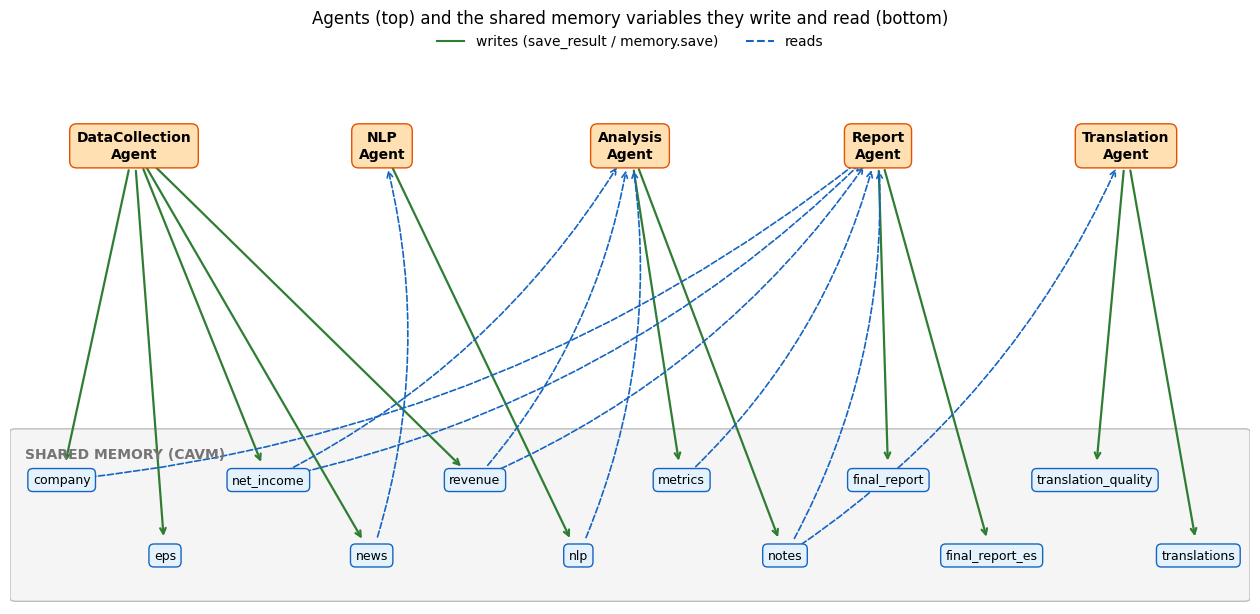

In [17]:
# 11d. How the agents shared memory (the paper's CAVM idea, drawn from memory.vars)
import matplotlib.pyplot as plt

AGENT_ORDER = ["DataCollectionAgent", "NLPAgent", "AnalysisAgent", "ReportAgent", "TranslationAgent"]
READS = {"NLPAgent": ["news"], "AnalysisAgent": ["revenue", "net_income", "nlp"],      # what each agent reads (by design)
         "ReportAgent": ["company", "revenue", "net_income", "notes", "metrics"], "TranslationAgent": ["notes"]}

def var_group(name):                     # revenue_NVDA, revenue_AMD -> "revenue"
    for t in TICKERS:
        if name.endswith("_" + vname(t)):
            return name[: -len(vname(t)) - 1]
    return name

writes = {}
for name, info in memory.vars.items():
    if info["value"] is not None:
        writes.setdefault(var_group(name), info["agent"])
agents = [a for a in AGENT_ORDER if a in writes.values() or a in READS and any(g in writes for g in READS[a])]
variables = sorted(writes, key=lambda g: (AGENT_ORDER.index(writes[g]) if writes[g] in AGENT_ORDER else 99, g))

fig, ax = plt.subplots(figsize=(16, 7))
ax_pos = {a: ((i + 0.5) / len(agents), 0.85) for i, a in enumerate(agents)}
var_pos = {g: ((i + 0.5) / len(variables), 0.09 if i % 2 else 0.23) for i, g in enumerate(variables)}  # staggered rows
for g, a in writes.items():
    if a in ax_pos:
        ax.annotate("", xy=var_pos[g], xytext=ax_pos[a],
                    arrowprops=dict(arrowstyle="->", color="#2e7d32", lw=1.6, shrinkA=18, shrinkB=14))
for a, groups in READS.items():
    for g in groups:
        if a in ax_pos and g in var_pos:
            ax.annotate("", xy=ax_pos[a], xytext=var_pos[g],
                        arrowprops=dict(arrowstyle="->", color="#1565c0", lw=1.2, ls="--", shrinkA=14, shrinkB=18,
                                        connectionstyle="arc3,rad=0.15"))
for a, (x, y) in ax_pos.items():
    ax.text(x, y, a.replace("Agent", "\nAgent"), ha="center", va="center", fontsize=10, weight="bold",
            bbox=dict(boxstyle="round,pad=0.5", fc="#ffe0b2", ec="#e65100"))
for g, (x, y) in var_pos.items():
    ax.text(x, y, g, ha="center", va="center", fontsize=9, bbox=dict(boxstyle="round,pad=0.4", fc="#e3f2fd", ec="#1565c0"))
from matplotlib.patches import FancyBboxPatch
ax.add_patch(FancyBboxPatch((0.005, 0.01), 0.99, 0.31, boxstyle="round,pad=0.005", fc="#f5f5f5", ec="#bdbdbd", zorder=0))
ax.text(0.012, 0.29, "SHARED MEMORY (CAVM)", fontsize=10, color="#757575", weight="bold", va="top")
ax.plot([], [], color="#2e7d32", label="writes (save_result / memory.save)")
ax.plot([], [], color="#1565c0", ls="--", label="reads")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
plt.title("Agents (top) and the shared memory variables they write and read (bottom)", pad=30)
plt.show()

In [18]:
# 11e. Trust panel: how much of the brief is backed by citations, and by which kind of source
body = memory.get("final_report", "").split("## Sources")[0]
bullets = [l for l in body.splitlines() if l.strip().startswith(("-", "*"))]
coverage = 100 * sum(bool(re.search(r"\[S\d+\]", l)) for l in bullets) / max(len(bullets), 1)
used = check_citations(body)[0]
kinds = pd.Series(["SEC filing" if "SEC XBRL" in memory.sources[s]["citation"] else "News article" for s in used]).value_counts()

fig = make_subplots(rows=1, cols=2, specs=[[{"type": "indicator"}, {"type": "pie"}]],
                    subplot_titles=("Bullet points with a citation", "Cited sources by type"))
fig.add_trace(go.Indicator(mode="gauge+number", value=round(coverage, 1), number={"suffix": "%"},
                           gauge={"axis": {"range": [0, 100]}, "bar": {"color": "#2e7d32"}}), row=1, col=1)
fig.add_trace(go.Pie(labels=list(kinds.index), values=list(kinds.values), hole=0.45), row=1, col=2)
fig.update_layout(title="Trust panel for the final brief", height=380)
fig.show()
print(f"{len(used)} distinct sources cited; {len(bullets)} bullet points, {coverage:.0f}% of them cite a source.")

7 distinct sources cited; 13 bullet points, 69% of them cite a source.


In [19]:
print("ACTIVITY LOG:\n" + "\n".join("  " + l for l in memory.log))
print(f"\nSOURCES REGISTERED: {len(memory.sources)}\n\nMEMORY CONTENTS:\n" + memory.describe())

ACTIVITY LOG:
  [DataCollectionAgent] saved 'company_NVDA'
  [DataCollectionAgent] saved 'revenue_NVDA'
  [DataCollectionAgent] saved 'net_income_NVDA'
  [DataCollectionAgent] saved 'eps_NVDA'
  [DataCollectionAgent] saved 'news_NVDA'
  [DataCollectionAgent] saved 'company_AMD'
  [DataCollectionAgent] saved 'revenue_AMD'
  [DataCollectionAgent] saved 'net_income_AMD'
  [DataCollectionAgent] saved 'eps_AMD'
  [NLPAgent] saved 'nlp_NVDA'
  [AnalysisAgent] saved 'notes_NVDA'
  [AnalysisAgent] saved 'metrics_NVDA'
  [AnalysisAgent] saved 'notes_AMD'
  [AnalysisAgent] saved 'metrics_AMD'
  [ReportAgent] saved 'final_report'
  [ReportAgent] saved 'final_report_es'
  [TranslationAgent] saved 'translations'
  [TranslationAgent] saved 'translation_quality'

SOURCES REGISTERED: 14

MEMORY CONTENTS:
- company_NVDA: Basic info for NVDA (by DataCollectionAgent)
- revenue_NVDA: NVDA quarterly revenue (Revenues), 8 quarter(s) (by DataCollectionAgent)
- net_income_NVDA: NVDA quarterly net_income (NetI

## NLP tasks covered so far → and what the team adds next
| Covered here | Model / API | Still to add in the real system |
|---|---|---|
| Sentiment analysis | FinBERT | Earnings-call tone (management vs analysts) |
| Named entity recognition | bert-base-NER | Tickers, products, executives (finance NER) |
| Text classification | BART-MNLI zero-shot | Document type (10-K/10-Q/8-K/news) |
| Machine translation | opus-mt-en-es, NLLB-200 (es, zh, vi, hi) + number check + round-trip chrF | Human-rated quality, glossary for finance terms |
| Text generation, QA, dialogue | HF Inference Providers LLM | Retrieval over full filing text with section-level citations |
| Information extraction | SEC XBRL | Guidance, risks, events from text |
| — | — | Speech recognition (Whisper on call audio), summarization, topic modeling, similarity, coreference, spelling correction |

Suggested owners (team of 5): Data Collection Agent · NLP Agent · Analysis Agent · Report/Q&A Agent · Memory + UI + deployment.